# April 30 Plots

This notebook reads the `runner_April30th` sweep logs and plots:

- two-qubit gate error sweep
- one-qubit gate error sweep
- measurement error sweep
- physical Bell-pair error sweep


In [13]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.axes import Axes
from matplotlib.figure import Figure

sns.set_theme(style="whitegrid")

LOG_ROOT = Path("/Users/patange/Documents/Argonne/QEC/log/runner_April30th")

filename_re = re.compile(
    r"line_(?P<nodes>\d+)_2G,"
    r"code=(?P<code>\[\[.*?\]\]),"
    r"dist=(?P<dist>[0-9.]+),"
    r"gate=(?P<gate>[0-9.]+),"
    r"twoq=(?P<twoq>[0-9.]+),"
    r"meas=(?P<meas>[0-9.]+|cfg),"
    r"prep=(?P<prep>[0-9.]+),"
    r"T1=(?P<t1>[0-9.eE+-]+),"
    r"T2=(?P<t2>[0-9.eE+-]+),"
    r"ft=(?P<ft>[a-zA-Z0-9_]+),"
    r"pauli=(?P<pauli>[0-9._]+|cfg),"
    r"ccorr=(?P<ccorr>none|cec|qec\+cec|qec),"
    r"physbell=(?P<physbell>[0-9.]+|cfg),"
    r"ts=(?P<ts>\d{8}_\d{6})"
)

critical_e2e_re = re.compile(
    r"critical_e2e run_id=(?P<run_id>\d+) "
    r"latency_ps=(?P<latency_ps>[-+0-9.eE]+) "
    r"fidelity_corrected=(?P<fidelity_corrected>[-+0-9.eE]+)"
)


In [14]:
def parse_float_token(token: str) -> float:
    """Convert one filename token into a float.

    Args:
        token: Filename token to convert.

    Returns:
        float: Parsed float value, or NaN for cfg.
    """
    if token == "cfg":
        return np.nan
    return float(token)


def parse_log_metadata(path: Path) -> dict[str, str]:
    """Parse one sweep-log filename into metadata fields.

    Args:
        path: Log file path.

    Returns:
        dict[str, str]: Parsed filename metadata fields.
    """
    match = filename_re.search(path.name)
    if match is None:
        raise ValueError(f"bad log filename: {path.name}")
    return match.groupdict()


def load_run_data(log_dir: Path) -> pd.DataFrame:
    """Load run-level corrected fidelity data from one sweep directory.

    Args:
        log_dir: Directory containing per-point sweep log files.

    Returns:
        pd.DataFrame: One row per logged completed run.
    """
    rows: list[dict[str, float | int | str]] = []

    if not log_dir.exists():
        raise FileNotFoundError(f"missing log directory: {log_dir}")

    for path in sorted(log_dir.iterdir()):
        if not path.is_file() or path.stat().st_size == 0:
            continue

        metadata = parse_log_metadata(path)
        for line in path.read_text().splitlines():
            match = critical_e2e_re.search(line)
            if match is None:
                continue

            rows.append(
                {
                    "log_file": path.name,
                    "nodes": int(metadata["nodes"]),
                    "code": metadata["code"],
                    "distance_km": float(metadata["dist"]),
                    "gate_fidelity": float(metadata["gate"]),
                    "two_qubit_gate_fidelity": float(metadata["twoq"]),
                    "measurement_fidelity": parse_float_token(metadata["meas"]),
                    "initialization_fidelity": float(metadata["prep"]),
                    "idle_t1_sec": float(metadata["t1"]),
                    "idle_t2_sec": float(metadata["t2"]),
                    "ft_prep_mode": metadata["ft"],
                    "correction_mode": metadata["ccorr"],
                    "physical_bell_pair_fidelity": parse_float_token(metadata["physbell"]),
                    "timestamp_tag": metadata["ts"],
                    "run_id": int(match["run_id"]),
                    "latency_ps": float(match["latency_ps"]),
                    "fidelity_corrected": float(match["fidelity_corrected"]),
                }
            )

    return pd.DataFrame(rows)


def summarize_sweep(run_df: pd.DataFrame, sweep_column: str) -> pd.DataFrame:
    """Aggregate one sweep into mean corrected fidelity and latency.

    Args:
        run_df: Flat run-level dataframe.
        sweep_column: Column being swept on the x-axis.

    Returns:
        pd.DataFrame: Aggregated sweep summary.
    """
    summary_df = (
        run_df.groupby(sweep_column, as_index=False)
        .agg(
            fidelity_corrected=("fidelity_corrected", "mean"),
            avg_latency_ps=("latency_ps", "mean"),
            run_count=("run_id", "count"),
        )
        .sort_values(sweep_column)
        .reset_index(drop=True)
    )
    summary_df["error_rate"] = 1.0 - summary_df[sweep_column]
    return summary_df


def set_zoom_limits(ax: Axes, x_values: pd.Series, y_values: pd.Series) -> None:
    """Set compact axis limits around one sweep curve.

    Args:
        ax: Target axes.
        x_values: Sweep x-values.
        y_values: Sweep y-values.

    Returns:
        None.
    """
    x_min = float(x_values.min())
    x_max = float(x_values.max())
    y_min = float(y_values.min())
    y_max = float(y_values.max())

    x_pad = max((x_max - x_min) * 0.08, 0.0005)
    y_pad = max((y_max - y_min) * 0.12, 0.0005)

    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(max(0.0, y_min - y_pad), min(1.01, y_max + y_pad))


def plot_sweep(summary_df: pd.DataFrame, sweep_column: str, x_label: str, title: str) -> tuple[Figure, Axes]:
    """Plot corrected logical fidelity against one swept fidelity parameter.

    Args:
        summary_df: Aggregated sweep dataframe.
        sweep_column: X-axis column name.
        x_label: Plot x-axis label.
        title: Plot title.

    Returns:
        tuple[Figure, Axes]: Created figure and axes.
    """
    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.plot(
        summary_df[sweep_column],
        summary_df["fidelity_corrected"],
        marker="s",
        markersize=7,
        linewidth=2.5,
        color="black",
        label="corrected logical fidelity",
    )
    ax.plot(
        summary_df[sweep_column],
        summary_df[sweep_column],
        linestyle="--",
        linewidth=1.5,
        color="#7f7f7f",
        alpha=0.8,
        label="y = x",
    )
    ax.set_xlabel(x_label)
    ax.set_ylabel("end-to-end logical fidelity")
    ax.set_title(title)
    set_zoom_limits(ax, summary_df[sweep_column], summary_df["fidelity_corrected"])
    ax.legend()
    ax.grid(True, alpha=0.3)
    return fig, ax


def save_figure(fig: Figure, file_name: str) -> Path:
    """Save one figure under the April 30 log root.

    Args:
        fig: Figure to save.
        file_name: Output PNG filename.

    Returns:
        Path: Saved file path.
    """
    out_path = LOG_ROOT / file_name
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    return out_path


In [15]:
LOG_DIR_TWOQ = LOG_ROOT / "graph_two_qubit_gate_sweep_only_2q_noise"

run_df_twoq = load_run_data(LOG_DIR_TWOQ)
summary_df_twoq_line2 = summarize_sweep(run_df_twoq.loc[run_df_twoq["nodes"] == 2].copy(), "two_qubit_gate_fidelity")
summary_df_twoq_line3 = summarize_sweep(run_df_twoq.loc[run_df_twoq["nodes"] == 3].copy(), "two_qubit_gate_fidelity")

summary_df_twoq_line2


,two_qubit_gate_fidelity,fidelity_corrected,avg_latency_ps,run_count,error_rate
0,0.9900,0.9820,1.506940e+10,5000,0.0100
1,0.9910,0.9844,1.509595e+10,5000,0.0090
2,0.9920,0.9876,1.516717e+10,5000,0.0080
3,0.9930,0.9892,1.509761e+10,5000,0.0070
4,0.9940,0.9926,1.512925e+10,5000,0.0060
5,0.9950,0.9936,1.517411e+10,5000,0.0050
6,0.9960,0.9960,1.512628e+10,5000,0.0040
7,0.9970,0.9978,1.517422e+10,5000,0.0030
8,0.9980,0.9992,1.503146e+10,5000,0.0020
9,0.9990,1.0000,1.510021e+10,5000,0.0010


In [19]:
summary_df_twoq_line3

,two_qubit_gate_fidelity,fidelity_corrected,avg_latency_ps,run_count,error_rate
0,0.9900,0.9348,1.858071e+10,5000,0.0100
1,0.9910,0.9534,1.873685e+10,5000,0.0090
2,0.9920,0.9548,1.866674e+10,5000,0.0080
3,0.9930,0.9650,1.873933e+10,5000,0.0070
4,0.9940,0.9776,1.862768e+10,5000,0.0060
5,0.9950,0.9850,1.858606e+10,5000,0.0050
6,0.9960,0.9860,1.862284e+10,5000,0.0040
7,0.9970,0.9936,1.864164e+10,5000,0.0030
8,0.9980,0.9970,1.869022e+10,5000,0.0020
9,0.9990,0.9990,1.870963e+10,5000,0.0010


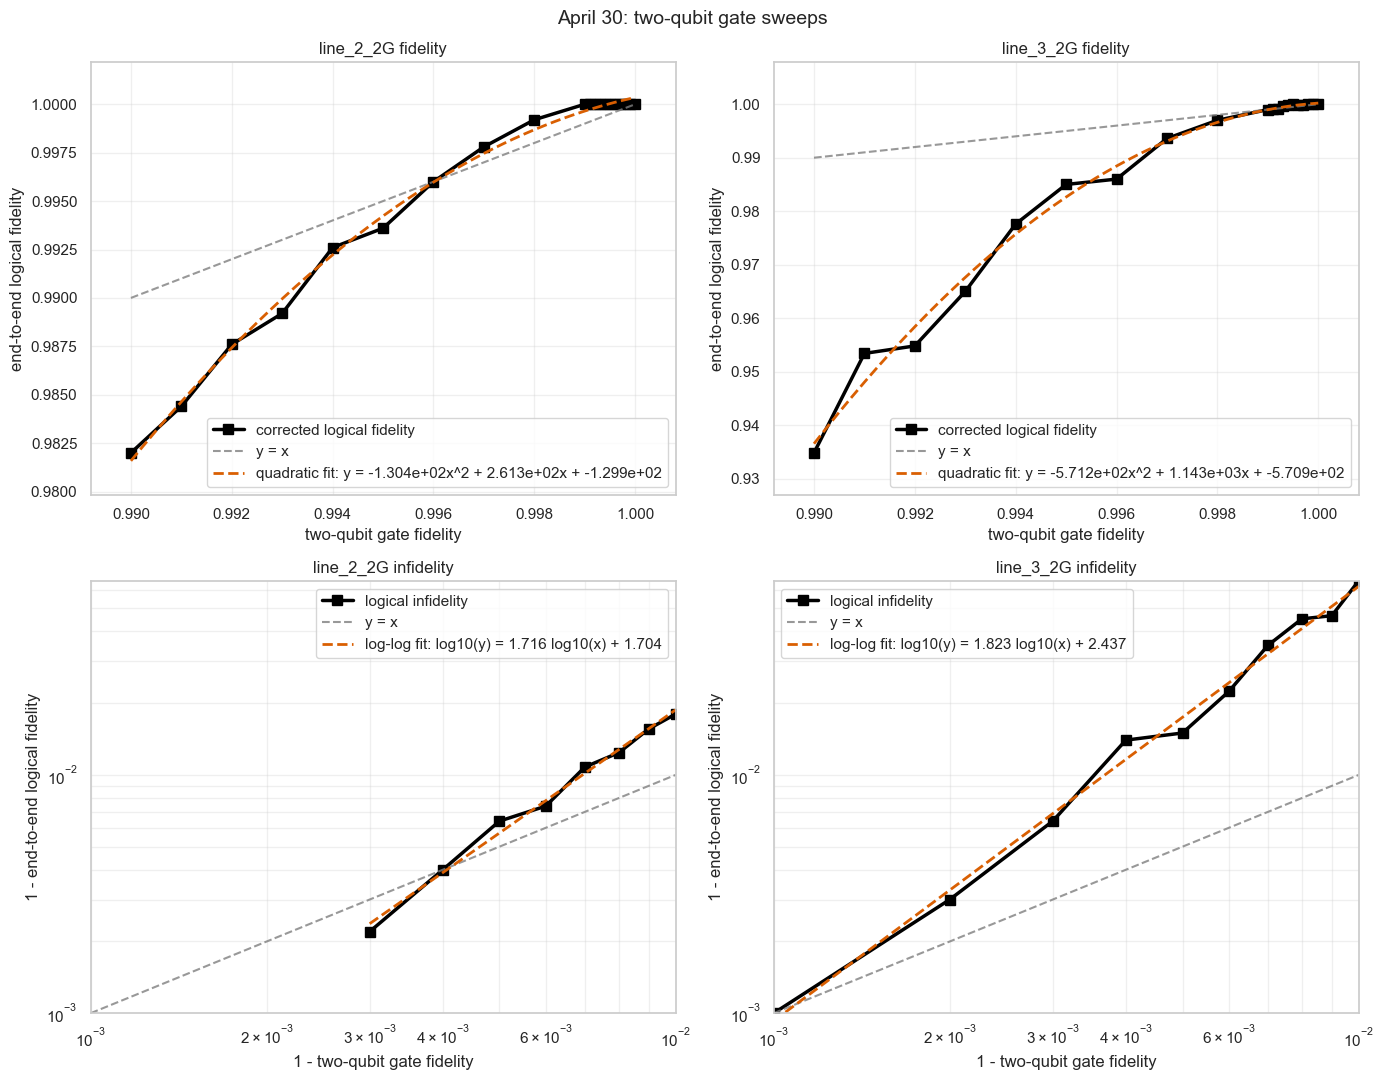

PosixPath('/Users/patange/Documents/Argonne/QEC/log/runner_April30th/april30_two_qubit_gate_2x2.png')

In [16]:
plot_df_twoq_line2 = summary_df_twoq_line2.copy()
plot_df_twoq_line2["twoq_error"] = 1.0 - plot_df_twoq_line2["two_qubit_gate_fidelity"]
plot_df_twoq_line2["logical_error"] = 1.0 - plot_df_twoq_line2["fidelity_corrected"]
plot_df_twoq_line2 = plot_df_twoq_line2.loc[(plot_df_twoq_line2["twoq_error"] > 0.0) & (plot_df_twoq_line2["logical_error"] > 1e-3)].copy()

plot_df_twoq_line3 = summary_df_twoq_line3.copy()
plot_df_twoq_line3["twoq_error"] = 1.0 - plot_df_twoq_line3["two_qubit_gate_fidelity"]
plot_df_twoq_line3["logical_error"] = 1.0 - plot_df_twoq_line3["fidelity_corrected"]
plot_df_twoq_line3 = plot_df_twoq_line3.loc[(plot_df_twoq_line3["twoq_error"] > 0.0) & (plot_df_twoq_line3["logical_error"] > 1e-3)].copy()

quad_line2 = np.polyfit(summary_df_twoq_line2["two_qubit_gate_fidelity"], summary_df_twoq_line2["fidelity_corrected"], 2)
quad_line3 = np.polyfit(summary_df_twoq_line3["two_qubit_gate_fidelity"], summary_df_twoq_line3["fidelity_corrected"], 2)
fit_line2 = np.polyfit(np.log10(plot_df_twoq_line2["twoq_error"]), np.log10(plot_df_twoq_line2["logical_error"]), 1)
fit_line3 = np.polyfit(np.log10(plot_df_twoq_line3["twoq_error"]), np.log10(plot_df_twoq_line3["logical_error"]), 1)
quad_line2_label = f"quadratic fit: y = {quad_line2[0]:.3e}x^2 + {quad_line2[1]:.3e}x + {quad_line2[2]:.3e}"
quad_line3_label = f"quadratic fit: y = {quad_line3[0]:.3e}x^2 + {quad_line3[1]:.3e}x + {quad_line3[2]:.3e}"
fit_line2_label = f"log-log fit: log10(y) = {fit_line2[0]:.3f} log10(x) + {fit_line2[1]:.3f}"
fit_line3_label = f"log-log fit: log10(y) = {fit_line3[0]:.3f} log10(x) + {fit_line3[1]:.3f}"

x_quad_line2 = np.linspace(summary_df_twoq_line2["two_qubit_gate_fidelity"].min(), summary_df_twoq_line2["two_qubit_gate_fidelity"].max(), 200)
y_quad_line2 = np.polyval(quad_line2, x_quad_line2)
x_quad_line3 = np.linspace(summary_df_twoq_line3["two_qubit_gate_fidelity"].min(), summary_df_twoq_line3["two_qubit_gate_fidelity"].max(), 200)
y_quad_line3 = np.polyval(quad_line3, x_quad_line3)

x_fit_line2 = np.logspace(np.log10(plot_df_twoq_line2["twoq_error"].min()), np.log10(plot_df_twoq_line2["twoq_error"].max()), 200)
y_fit_line2 = 10 ** fit_line2[1] * x_fit_line2 ** fit_line2[0]
x_fit_line3 = np.logspace(np.log10(plot_df_twoq_line3["twoq_error"].min()), np.log10(plot_df_twoq_line3["twoq_error"].max()), 200)
y_fit_line3 = 10 ** fit_line3[1] * x_fit_line3 ** fit_line3[0]

x_log_min = min(plot_df_twoq_line2["twoq_error"].min(), plot_df_twoq_line3["twoq_error"].min())
x_log_max = max(plot_df_twoq_line2["twoq_error"].max(), plot_df_twoq_line3["twoq_error"].max())
y_log_min = 1e-3
y_log_max = max(plot_df_twoq_line2["logical_error"].max(), plot_df_twoq_line3["logical_error"].max())

fig_twoq, axes_twoq = plt.subplots(2, 2, figsize=(14, 11))

ax_line2_fidelity = axes_twoq[0, 0]
ax_line3_fidelity = axes_twoq[0, 1]
ax_line2_infidelity = axes_twoq[1, 0]
ax_line3_infidelity = axes_twoq[1, 1]

ax_line2_fidelity.plot(summary_df_twoq_line2["two_qubit_gate_fidelity"], summary_df_twoq_line2["fidelity_corrected"], marker="s", markersize=7, linewidth=2.5, color="black", label="corrected logical fidelity")
ax_line2_fidelity.plot(summary_df_twoq_line2["two_qubit_gate_fidelity"], summary_df_twoq_line2["two_qubit_gate_fidelity"], linestyle="--", linewidth=1.5, color="#7f7f7f", alpha=0.8, label="y = x")
ax_line2_fidelity.plot(x_quad_line2, y_quad_line2, linestyle="--", linewidth=2, color="#d95f02", label=quad_line2_label)
ax_line2_fidelity.set_xlabel("two-qubit gate fidelity")
ax_line2_fidelity.set_ylabel("end-to-end logical fidelity")
ax_line2_fidelity.set_title("line_2_2G fidelity")
set_zoom_limits(ax_line2_fidelity, summary_df_twoq_line2["two_qubit_gate_fidelity"], summary_df_twoq_line2["fidelity_corrected"])
ax_line2_fidelity.legend()
ax_line2_fidelity.grid(True, alpha=0.3)

ax_line3_fidelity.plot(summary_df_twoq_line3["two_qubit_gate_fidelity"], summary_df_twoq_line3["fidelity_corrected"], marker="s", markersize=7, linewidth=2.5, color="black", label="corrected logical fidelity")
ax_line3_fidelity.plot(summary_df_twoq_line3["two_qubit_gate_fidelity"], summary_df_twoq_line3["two_qubit_gate_fidelity"], linestyle="--", linewidth=1.5, color="#7f7f7f", alpha=0.8, label="y = x")
ax_line3_fidelity.plot(x_quad_line3, y_quad_line3, linestyle="--", linewidth=2, color="#d95f02", label=quad_line3_label)
ax_line3_fidelity.set_xlabel("two-qubit gate fidelity")
ax_line3_fidelity.set_ylabel("end-to-end logical fidelity")
ax_line3_fidelity.set_title("line_3_2G fidelity")
set_zoom_limits(ax_line3_fidelity, summary_df_twoq_line3["two_qubit_gate_fidelity"], summary_df_twoq_line3["fidelity_corrected"])
ax_line3_fidelity.legend()
ax_line3_fidelity.grid(True, alpha=0.3)

ax_line2_infidelity.plot(plot_df_twoq_line2["twoq_error"], plot_df_twoq_line2["logical_error"], marker="s", markersize=7, linewidth=2.5, color="black", label="logical infidelity")
ax_line2_infidelity.plot([x_log_min, x_log_max], [x_log_min, x_log_max], linestyle="--", linewidth=1.5, color="#7f7f7f", alpha=0.8, label="y = x")
ax_line2_infidelity.plot(x_fit_line2, y_fit_line2, linestyle="--", linewidth=2, color="#d95f02", label=fit_line2_label)
ax_line2_infidelity.set_xscale("log")
ax_line2_infidelity.set_yscale("log")
ax_line2_infidelity.set_xlabel("1 - two-qubit gate fidelity")
ax_line2_infidelity.set_ylabel("1 - end-to-end logical fidelity")
ax_line2_infidelity.set_title("line_2_2G infidelity")
ax_line2_infidelity.legend()
ax_line2_infidelity.grid(True, alpha=0.3, which="both")
ax_line2_infidelity.set_xlim(x_log_min, x_log_max)
ax_line2_infidelity.set_ylim(y_log_min, y_log_max)

ax_line3_infidelity.plot(plot_df_twoq_line3["twoq_error"], plot_df_twoq_line3["logical_error"], marker="s", markersize=7, linewidth=2.5, color="black", label="logical infidelity")
ax_line3_infidelity.plot([x_log_min, x_log_max], [x_log_min, x_log_max], linestyle="--", linewidth=1.5, color="#7f7f7f", alpha=0.8, label="y = x")
ax_line3_infidelity.plot(x_fit_line3, y_fit_line3, linestyle="--", linewidth=2, color="#d95f02", label=fit_line3_label)
ax_line3_infidelity.set_xscale("log")
ax_line3_infidelity.set_yscale("log")
ax_line3_infidelity.set_xlabel("1 - two-qubit gate fidelity")
ax_line3_infidelity.set_ylabel("1 - end-to-end logical fidelity")
ax_line3_infidelity.set_title("line_3_2G infidelity")
ax_line3_infidelity.legend()
ax_line3_infidelity.grid(True, alpha=0.3, which="both")
ax_line3_infidelity.set_xlim(x_log_min, x_log_max)
ax_line3_infidelity.set_ylim(y_log_min, y_log_max)

fig_twoq.suptitle("April 30: two-qubit gate sweeps", fontsize=14)
plt.tight_layout()
plt.show()

save_figure(fig_twoq, "april30_two_qubit_gate_2x2.png")


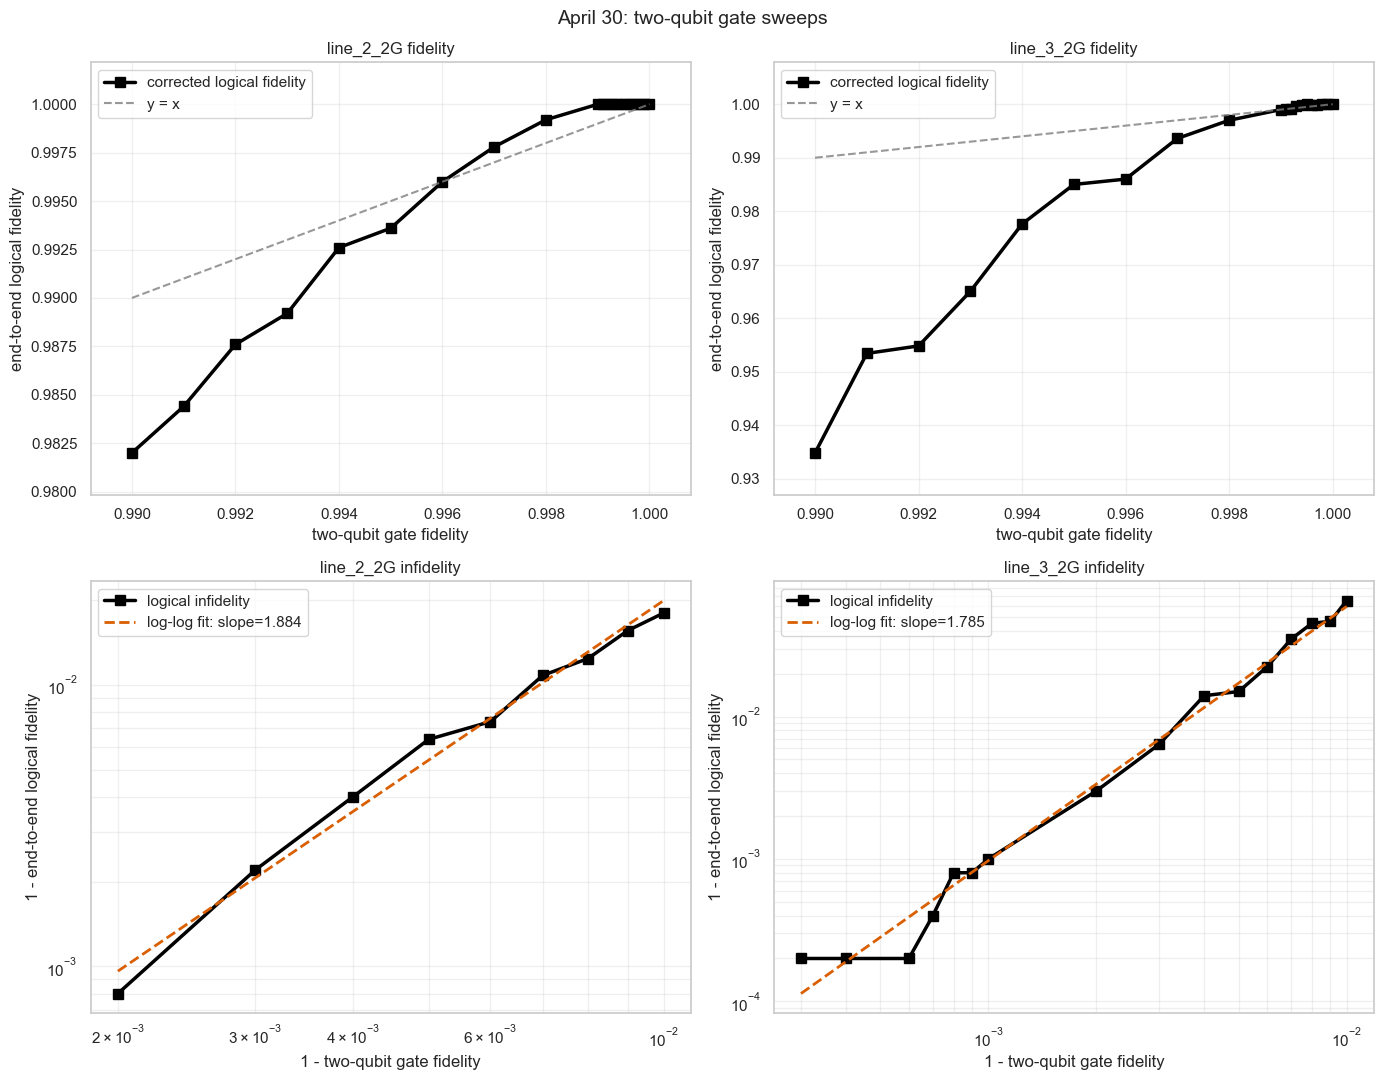

PosixPath('/Users/patange/Documents/Argonne/QEC/log/runner_April30th/april30_two_qubit_gate_2x2.png')

In [17]:
plot_df_twoq_line2 = summary_df_twoq_line2.copy()
plot_df_twoq_line2["twoq_error"] = 1.0 - plot_df_twoq_line2["two_qubit_gate_fidelity"]
plot_df_twoq_line2["logical_error"] = 1.0 - plot_df_twoq_line2["fidelity_corrected"]
plot_df_twoq_line2 = plot_df_twoq_line2.loc[
    (plot_df_twoq_line2["twoq_error"] > 0.0) & (plot_df_twoq_line2["logical_error"] > 0.0)
].copy()

plot_df_twoq_line3 = summary_df_twoq_line3.copy()
plot_df_twoq_line3["twoq_error"] = 1.0 - plot_df_twoq_line3["two_qubit_gate_fidelity"]
plot_df_twoq_line3["logical_error"] = 1.0 - plot_df_twoq_line3["fidelity_corrected"]
plot_df_twoq_line3 = plot_df_twoq_line3.loc[
    (plot_df_twoq_line3["twoq_error"] > 0.0) & (plot_df_twoq_line3["logical_error"] > 0.0)
].copy()

fit_line2 = np.polyfit(
    np.log10(plot_df_twoq_line2["twoq_error"]),
    np.log10(plot_df_twoq_line2["logical_error"]),
    1,
)
fit_line3 = np.polyfit(
    np.log10(plot_df_twoq_line3["twoq_error"]),
    np.log10(plot_df_twoq_line3["logical_error"]),
    1,
)

x_fit_line2 = np.logspace(
    np.log10(plot_df_twoq_line2["twoq_error"].min()),
    np.log10(plot_df_twoq_line2["twoq_error"].max()),
    200,
)
y_fit_line2 = 10 ** (fit_line2[1]) * x_fit_line2 ** fit_line2[0]

x_fit_line3 = np.logspace(
    np.log10(plot_df_twoq_line3["twoq_error"].min()),
    np.log10(plot_df_twoq_line3["twoq_error"].max()),
    200,
)
y_fit_line3 = 10 ** (fit_line3[1]) * x_fit_line3 ** fit_line3[0]

fig_twoq, axes_twoq = plt.subplots(2, 2, figsize=(14, 11))

ax_line2_fidelity = axes_twoq[0, 0]
ax_line3_fidelity = axes_twoq[0, 1]
ax_line2_infidelity = axes_twoq[1, 0]
ax_line3_infidelity = axes_twoq[1, 1]

ax_line2_fidelity.plot(
    summary_df_twoq_line2["two_qubit_gate_fidelity"],
    summary_df_twoq_line2["fidelity_corrected"],
    marker="s",
    markersize=7,
    linewidth=2.5,
    color="black",
    label="corrected logical fidelity",
)
ax_line2_fidelity.plot(
    summary_df_twoq_line2["two_qubit_gate_fidelity"],
    summary_df_twoq_line2["two_qubit_gate_fidelity"],
    linestyle="--",
    linewidth=1.5,
    color="#7f7f7f",
    alpha=0.8,
    label="y = x",
)
ax_line2_fidelity.set_xlabel("two-qubit gate fidelity")
ax_line2_fidelity.set_ylabel("end-to-end logical fidelity")
ax_line2_fidelity.set_title("line_2_2G fidelity")
set_zoom_limits(
    ax_line2_fidelity,
    summary_df_twoq_line2["two_qubit_gate_fidelity"],
    summary_df_twoq_line2["fidelity_corrected"],
)
ax_line2_fidelity.legend()
ax_line2_fidelity.grid(True, alpha=0.3)

ax_line3_fidelity.plot(
    summary_df_twoq_line3["two_qubit_gate_fidelity"],
    summary_df_twoq_line3["fidelity_corrected"],
    marker="s",
    markersize=7,
    linewidth=2.5,
    color="black",
    label="corrected logical fidelity",
)
ax_line3_fidelity.plot(
    summary_df_twoq_line3["two_qubit_gate_fidelity"],
    summary_df_twoq_line3["two_qubit_gate_fidelity"],
    linestyle="--",
    linewidth=1.5,
    color="#7f7f7f",
    alpha=0.8,
    label="y = x",
)
ax_line3_fidelity.set_xlabel("two-qubit gate fidelity")
ax_line3_fidelity.set_ylabel("end-to-end logical fidelity")
ax_line3_fidelity.set_title("line_3_2G fidelity")
set_zoom_limits(
    ax_line3_fidelity,
    summary_df_twoq_line3["two_qubit_gate_fidelity"],
    summary_df_twoq_line3["fidelity_corrected"],
)
ax_line3_fidelity.legend()
ax_line3_fidelity.grid(True, alpha=0.3)

ax_line2_infidelity.plot(
    plot_df_twoq_line2["twoq_error"],
    plot_df_twoq_line2["logical_error"],
    marker="s",
    markersize=7,
    linewidth=2.5,
    color="black",
    label="logical infidelity",
)
ax_line2_infidelity.plot(
    x_fit_line2,
    y_fit_line2,
    linestyle="--",
    linewidth=2,
    color="#d95f02",
    label=f"log-log fit: slope={fit_line2[0]:.3f}",
)
ax_line2_infidelity.set_xscale("log")
ax_line2_infidelity.set_yscale("log")
ax_line2_infidelity.set_xlabel("1 - two-qubit gate fidelity")
ax_line2_infidelity.set_ylabel("1 - end-to-end logical fidelity")
ax_line2_infidelity.set_title("line_2_2G infidelity")
ax_line2_infidelity.legend()
ax_line2_infidelity.grid(True, alpha=0.3, which="both")

ax_line3_infidelity.plot(
    plot_df_twoq_line3["twoq_error"],
    plot_df_twoq_line3["logical_error"],
    marker="s",
    markersize=7,
    linewidth=2.5,
    color="black",
    label="logical infidelity",
)
ax_line3_infidelity.plot(
    x_fit_line3,
    y_fit_line3,
    linestyle="--",
    linewidth=2,
    color="#d95f02",
    label=f"log-log fit: slope={fit_line3[0]:.3f}",
)
ax_line3_infidelity.set_xscale("log")
ax_line3_infidelity.set_yscale("log")
ax_line3_infidelity.set_xlabel("1 - two-qubit gate fidelity")
ax_line3_infidelity.set_ylabel("1 - end-to-end logical fidelity")
ax_line3_infidelity.set_title("line_3_2G infidelity")
ax_line3_infidelity.legend()
ax_line3_infidelity.grid(True, alpha=0.3, which="both")

fig_twoq.suptitle("April 30: two-qubit gate sweeps", fontsize=14)
plt.tight_layout()
plt.show()

save_figure(fig_twoq, "april30_two_qubit_gate_2x2.png")


In [18]:
LOG_DIR_ONEQ = LOG_ROOT / "graph_one_qubit_gate_sweep_only_1q_noise"

run_df_oneq = load_run_data(LOG_DIR_ONEQ)
summary_df_oneq = summarize_sweep(run_df_oneq, "gate_fidelity")
summary_df_oneq


FileNotFoundError: missing log directory: /Users/patange/Documents/Argonne/QEC/log/runner_April30th/graph_one_qubit_gate_sweep_only_1q_noise

In [ ]:
fig_oneq, ax_oneq = plot_sweep(
    summary_df_oneq,
    "gate_fidelity",
    "one-qubit gate fidelity",
    "April 30: one-qubit gate error sweep",
)
plt.show()

save_figure(fig_oneq, "april30_one_qubit_gate_sweep.png")


In [ ]:
LOG_DIR_MEAS = LOG_ROOT / "graph_measurement_fidelity_sweep_only_meas_noise"

run_df_meas = load_run_data(LOG_DIR_MEAS)
summary_df_meas = summarize_sweep(run_df_meas, "measurement_fidelity")
summary_df_meas


In [ ]:
fig_meas, ax_meas = plot_sweep(
    summary_df_meas,
    "measurement_fidelity",
    "measurement fidelity",
    "April 30: measurement error sweep",
)
plt.show()

save_figure(fig_meas, "april30_measurement_sweep.png")


In [ ]:
LOG_DIR_BELL = LOG_ROOT / "graph_physical_bell_pair_fidelity_sweep"

run_df_bell = load_run_data(LOG_DIR_BELL)
summary_df_bell = summarize_sweep(run_df_bell, "physical_bell_pair_fidelity")
summary_df_bell


In [ ]:
fig_bell, ax_bell = plot_sweep(
    summary_df_bell,
    "physical_bell_pair_fidelity",
    "physical Bell-pair fidelity",
    "April 30: physical Bell-pair error sweep",
)
plt.show()

save_figure(fig_bell, "april30_physical_bell_pair_sweep.png")
